# Tuần 1 — EDA `dataset_phishing.csv`

**Người phụ trách:** Bạn B (lõi ML) · **Tham chiếu:** `Plan.md` mục 3 (Tuần 1), `CLAUDE.md` mục Dataset.

Mục tiêu notebook:

1. Kiểm tra cân bằng nhãn (kỳ vọng 50/50).
2. Phân phối đặc trưng + phát hiện cột hằng số / gần hằng số.
3. Xác nhận các cột hằng số = 0 (`CLAUDE.md` nói 3: `sfh`, `ratio_intErrors`, `ratio_intRedirection`).
4. Xác nhận `google_index` tương quan ~0.73 với nhãn.
5. Kiểm tra thiếu dữ liệu + sentinel `-1` của nhóm 7 đặc trưng tra cứu ngoài.

Toàn bộ tính toán nằm trong `src/eda.py`; notebook chỉ gọi lại + trình bày. Chạy `python -m src.eda` để sinh lại `reports/eda/`.

In [1]:
import sys, json
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import pandas as pd
pd.set_option('display.max_rows', 100)

from src import eda
from src.contracts import (
    FEATURE_NAMES, LEXICAL_FEATURES, CONTENT_FEATURES, EXTERNAL_FEATURES,
    CONSTANT_FEATURES_CLAUDE_MD, STRONGEST_SIGNAL_FEATURE,
)

df = eda.load_dataset()
print(f'{len(df):,} dòng x {df.shape[1]} cột  (url + {len(FEATURE_NAMES)} đặc trưng + status)')
print(f'Nhóm đặc trưng: {len(LEXICAL_FEATURES)} lexical | {len(CONTENT_FEATURES)} nội dung HTML | {len(EXTERNAL_FEATURES)} tra cứu ngoài')
df.head(3)

11,430 dòng x 89 cột  (url + 87 đặc trưng + status)
Nhóm đặc trưng: 56 lexical | 24 nội dung HTML | 7 tra cứu ngoài


,url,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,...,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank,status
0,http://www.crestonwood.com/router.php,37,19,0,3,0,0,0,0,0,...,0,1,0,45,-1,0,1,1,4,legitimate
1,http://shadetreetechnology.com/V4/validation/a...,77,23,1,1,0,0,0,0,0,...,1,0,0,77,5767,0,0,1,2,phishing
2,https://support-appleld.com.secureupdate.duila...,126,50,1,4,1,0,1,2,0,...,1,0,0,14,4004,5828815,0,1,0,phishing


## 1. Cân bằng nhãn

In [2]:
bal = eda.label_balance(df)
display(bal)
assert (bal['so_luong'] == 5715).all(), 'kỳ vọng 5715/5715'
print('OK — cân bằng chính xác 50/50, không cần class_weight hay resampling khi train.')
print('Lưu ý (Plan.md mục 6): traffic thật >99% hợp pháp — ngưỡng phân vùng phải hiệu chỉnh lại ở tuần 6, không chốt theo test set 50/50 này.')

,so_luong,ty_le
nhan,,
legitimate,5715,0.5
phishing,5715,0.5


OK — cân bằng chính xác 50/50, không cần class_weight hay resampling khi train.
Lưu ý (Plan.md mục 6): traffic thật >99% hợp pháp — ngưỡng phân vùng phải hiệu chỉnh lại ở tuần 6, không chốt theo test set 50/50 này.


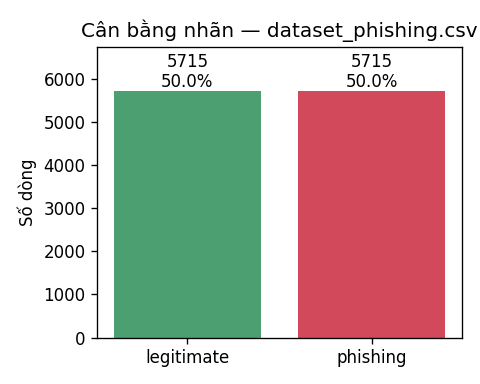

In [3]:
from IPython.display import Image
eda.plot_label_balance(df, eda.OUT_DIR / 'fig_label_balance.png')
Image(str(eda.OUT_DIR / 'fig_label_balance.png'))

## 2. Cột hằng số / gần hằng số

`CLAUDE.md` nói 3 cột = 0: `sfh`, `ratio_intErrors`, `ratio_intRedirection`. Kiểm tra lại toàn bộ 87 đặc trưng.

In [4]:
const = eda.constant_check(df)
zero_cols = const[(const['std'] == 0) & (const['max'] == 0) & (const['min'] == 0)]['dac_trung'].tolist()
print('Cột toàn bộ = 0 :', sorted(zero_cols))
print('CLAUDE.md liệt kê:', sorted(CONSTANT_FEATURES_CLAUDE_MD))
print('THÊM so với CLAUDE.md:', sorted(set(zero_cols) - set(CONSTANT_FEATURES_CLAUDE_MD)))
const.head(12)

Cột toàn bộ = 0 : ['nb_or', 'ratio_intErrors', 'ratio_intRedirection', 'ratio_nullHyperlinks', 'sfh', 'submit_email']
CLAUDE.md liệt kê: ['ratio_intErrors', 'ratio_intRedirection', 'sfh']
THÊM so với CLAUDE.md: ['nb_or', 'ratio_nullHyperlinks', 'submit_email']


,dac_trung,n_unique,min,max,std,gia_tri_duy_nhat
0,sfh,1,0.0,0.0,0.000000,0
1,ratio_intErrors,1,0.0,0.0,0.000000,0
2,submit_email,1,0.0,0.0,0.000000,0
3,nb_or,1,0.0,0.0,0.000000,0
4,ratio_intRedirection,1,0.0,0.0,0.000000,0
5,ratio_nullHyperlinks,1,0.0,0.0,0.000000,0
6,path_extension,2,0.0,1.0,0.013227,
7,punycode,2,0.0,1.0,0.018705,
8,nb_star,2,0.0,1.0,0.026448,
9,onmouseover,2,0.0,1.0,0.033707,


**Phát hiện:** dataset có **6** cột toàn số 0, không phải 3. Ngoài `sfh` / `ratio_intErrors` / `ratio_intRedirection` còn có `nb_or`, `ratio_nullHyperlinks`, `submit_email`.

→ Bỏ cả 6 khi feature selection (tuần 2). Đã ghi chú lại trong `docs/interface_contract.md` và cần cập nhật `CLAUDE.md`.

## 3. Tương quan với nhãn — xác nhận `google_index` ~0.73

In [5]:
corr = eda.target_correlation(df)
print(f"corr({STRONGEST_SIGNAL_FEATURE}, status) = {corr[STRONGEST_SIGNAL_FEATURE]:.4f}")
assert 0.70 <= abs(corr[STRONGEST_SIGNAL_FEATURE]) <= 0.76
corr.head(20).to_frame()

corr(google_index, status) = 0.7312


,pearson_r
dac_trung,
google_index,0.731171
page_rank,-0.511137
nb_www,-0.443468
ratio_digits_url,0.356395
domain_in_title,0.342807
nb_hyperlinks,-0.342628
phish_hints,0.335393
domain_age,-0.331889
ip,0.321698


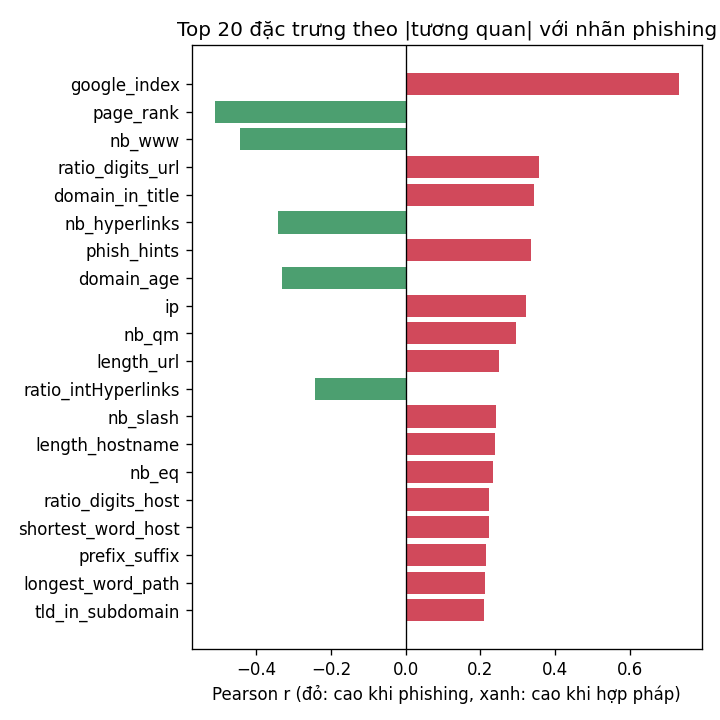

In [6]:
eda.plot_top_correlations(corr, eda.OUT_DIR / 'fig_top_correlations.png')
Image(str(eda.OUT_DIR / 'fig_top_correlations.png'))

`google_index` là tín hiệu đơn lẻ mạnh nhất (|r| ~0.73). `google_index = 1` (trang **không** được Google index) hầu như chỉ xuất hiện ở phishing. Rủi ro: đây là đặc trưng tra cứu ngoài (nhóm 7) — phụ thuộc dịch vụ Google, có thể chậm/không ổn định real-time và dễ concept drift. Cần theo dõi khi feature selection: nếu mô hình phụ thuộc quá nặng vào 1 đặc trưng ngoài dễ hỏng khi tra cứu lỗi.

## 4. Phân phối đặc trưng theo nhãn

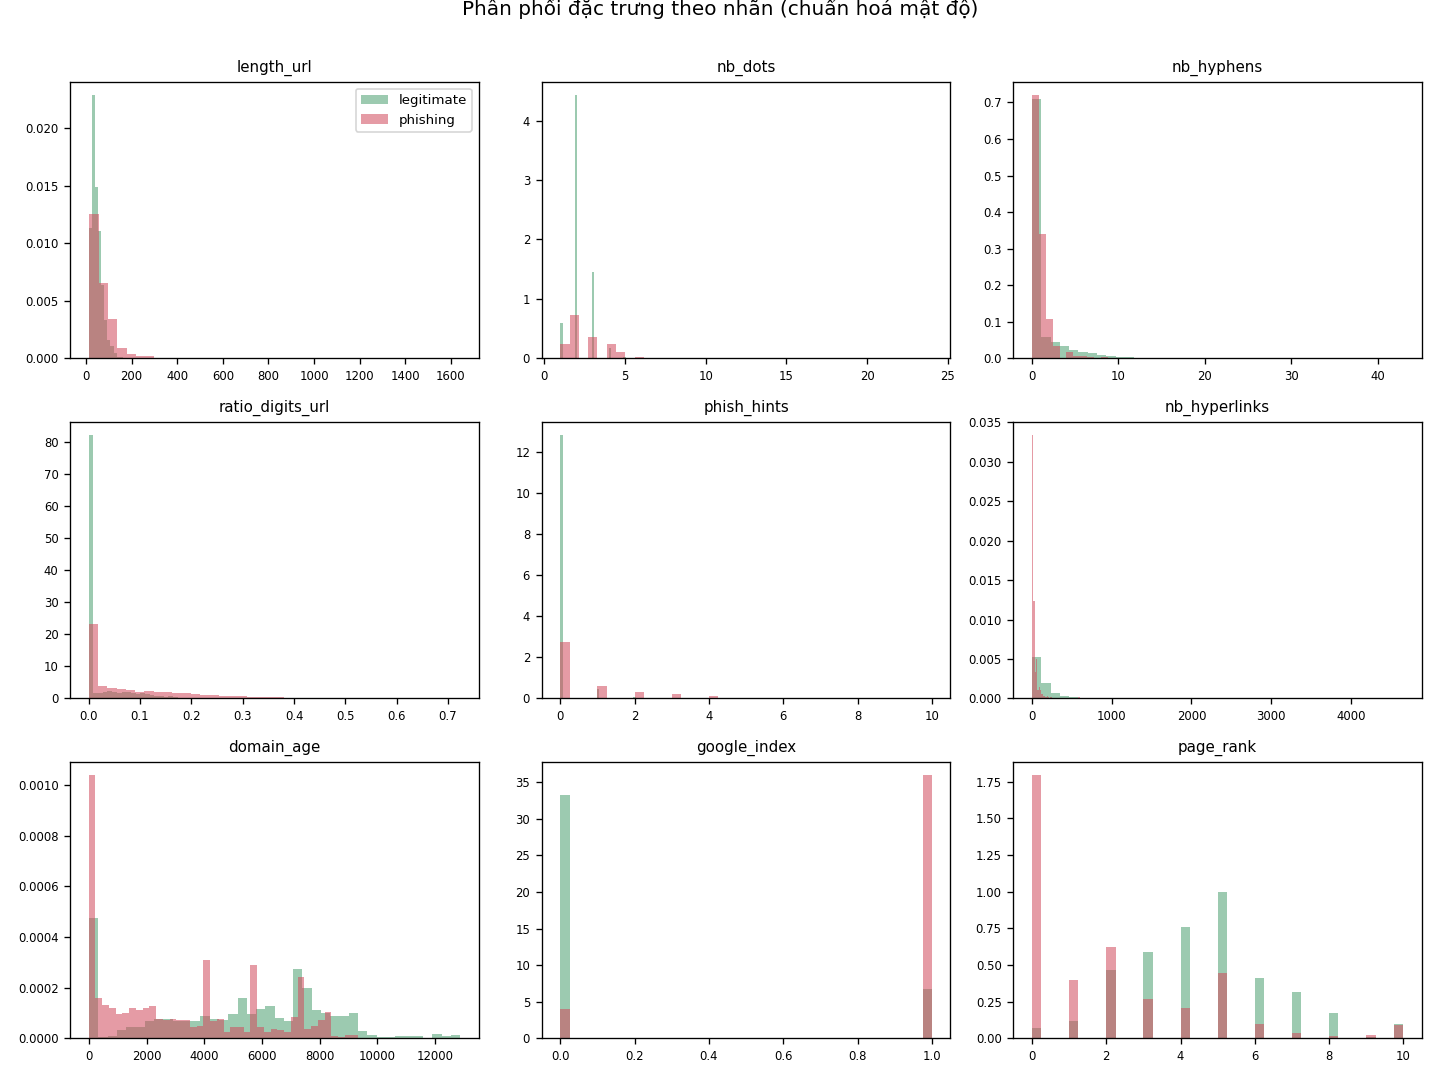

In [7]:
eda.plot_feature_distributions(
    df,
    ['length_url', 'nb_dots', 'nb_hyphens', 'ratio_digits_url', 'phish_hints',
     'nb_hyperlinks', 'domain_age', STRONGEST_SIGNAL_FEATURE, 'page_rank'],
    eda.OUT_DIR / 'fig_feature_distributions.png',
)
Image(str(eda.OUT_DIR / 'fig_feature_distributions.png'))

## 5. Thiếu dữ liệu + sentinel `-1` (nhóm tra cứu ngoài)

In [8]:
miss = eda.missing_and_sentinel(df)
print('Tổng ô NaN trên 87 đặc trưng:', int(miss['n_nan'].sum()))
miss[miss['ty_le_am_1'] > 0].sort_values('ty_le_am_1', ascending=False)

Tổng ô NaN trên 87 đặc trưng: 0


,dac_trung,n_nan,ty_le_am_1,nhom_ngoai
82,domain_age,0,0.155818,True
81,domain_registration_length,0,0.004024,True


Không có NaN. Nhưng `domain_age` có **~15.6%** giá trị `-1` = "không tra được tuổi domain" — đúng nhóm rủi ro *Domain ẩn WHOIS/RDAP* (`CLAUDE.md`). Khi train phải xử lý `-1` như hạng mục riêng (không coi là số năm bình thường), và Override #1 phải trả `"unknown"` chứ không mặc định an toàn cho các domain này.

## 6. Tóm tắt sang `reports/eda/`

Chạy `eda.run()` để ghi toàn bộ bảng + biểu đồ + `summary.json` + `BAO_CAO_EDA.md` chốt lại.

In [9]:
summary = eda.run()
print(json.dumps(summary, ensure_ascii=False, indent=2))

{
  "n_rows": 11430,
  "n_features": 87,
  "label_counts": {
    "legitimate": 5715,
    "phishing": 5715
  },
  "label_ratio": {
    "legitimate": 0.5,
    "phishing": 0.5
  },
  "duplicated_rows": 0,
  "duplicated_urls": 1,
  "constant_zero_features": [
    "nb_or",
    "ratio_intErrors",
    "ratio_intRedirection",
    "ratio_nullHyperlinks",
    "sfh",
    "submit_email"
  ],
  "near_constant_features(std<1e-6)": [
    "nb_or",
    "ratio_intErrors",
    "ratio_intRedirection",
    "ratio_nullHyperlinks",
    "sfh",
    "submit_email"
  ],
  "expected_constant(CLAUDE.md)": [
    "sfh",
    "ratio_intErrors",
    "ratio_intRedirection"
  ],
  "constant_check_matches_claude_md": false,
  "extra_zero_features_not_in_claude_md": [
    "nb_or",
    "ratio_nullHyperlinks",
    "submit_email"
  ],
  "corr_google_index": 0.7312,
  "top10_abs_corr": {
    "google_index": 0.7312,
    "page_rank": -0.5111,
    "nb_www": -0.4435,
    "ratio_digits_url": 0.3564,
    "domain_in_title": 0.3428,
 